
# Intrusion Detection Results Analysis Notebook

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_results():
    # New base path for CSV files
    base_path = "/mnt/AI-DATA/alara/CiberIA_O1/Data"
    
    # Define file paths for each dataset
    files = {
        "CIC-IDS2017": os.path.join(base_path, "Results_CIC_IDS_2017.csv"),
        "CIC-IDS2018": os.path.join(base_path, "Results_CIC_IDS_2018.csv"),
        "CIC-DDoS2019": os.path.join(base_path, "Results_CIC_IDS_2019.csv"),
        "UNSW-NB15": os.path.join(base_path, "Results_UNSW_NB15.csv")
    }
    
    # Load CSV files into DataFrames (assumes that CSVs have preprocessing as index and models as columns)
    results = {}
    for dataset, file_path in files.items():
        results[dataset] = pd.read_csv(file_path, index_col=0)
        
    return results

In [4]:
results = load_results()
print(results)

{'CIC-IDS2017':              Acc_NO-SMOTE_PCA  F1_NO-SMOTE_PCA  Time (s)_NO-SMOTE_PCA  \
Model                                                                   
RF                   0.999643         0.983104               3.904189   
k-NN                 0.999214         0.984169               1.434254   
LGBM                 0.999690         0.983401               1.838873   
NN                   0.999548         0.984957              57.029838   
XGBoost              0.999786         0.993285               1.719820   
SVM                  0.999024         0.938000             636.844062   
LR[RF+LGBM]          0.999786         0.991555             723.434739   

             Acc_NO-SMOTE_TopK  F1_NO-SMOTE_TopK  Time (s)_NO-SMOTE_TopK  \
Model                                                                      
RF                    0.999952          0.997664                1.419226   
k-NN                  0.976000          0.825105                2.183080   
LGBM                  

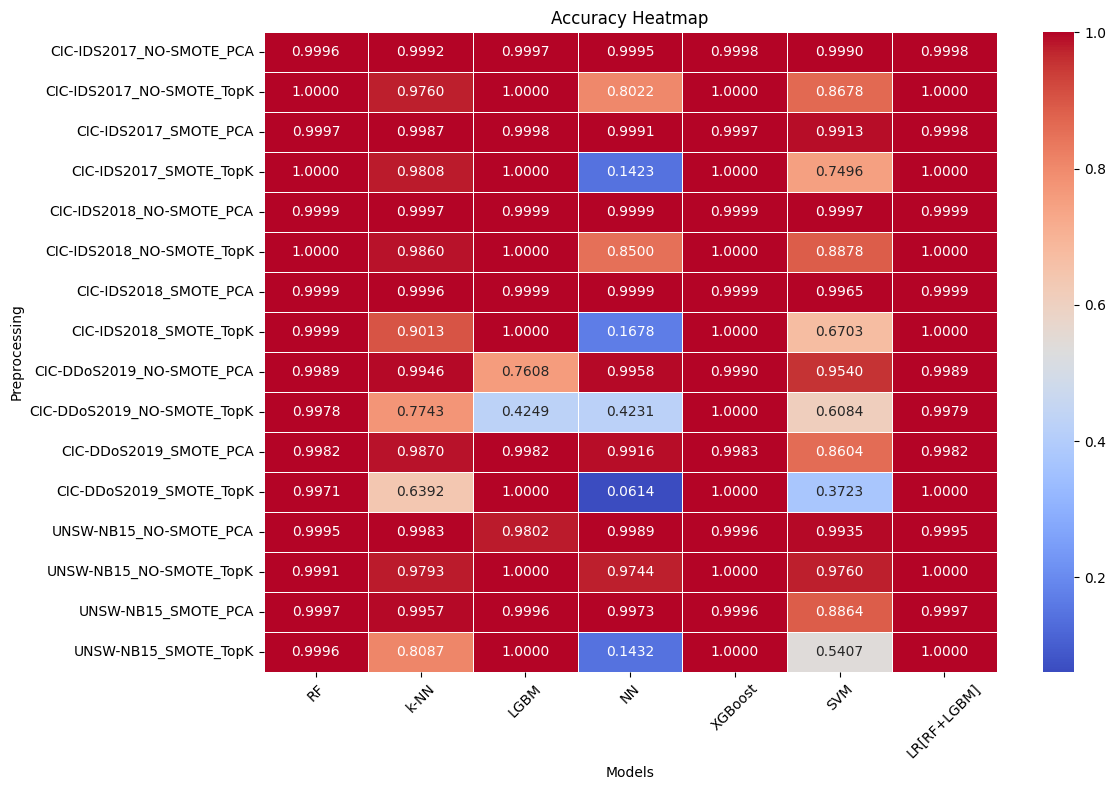

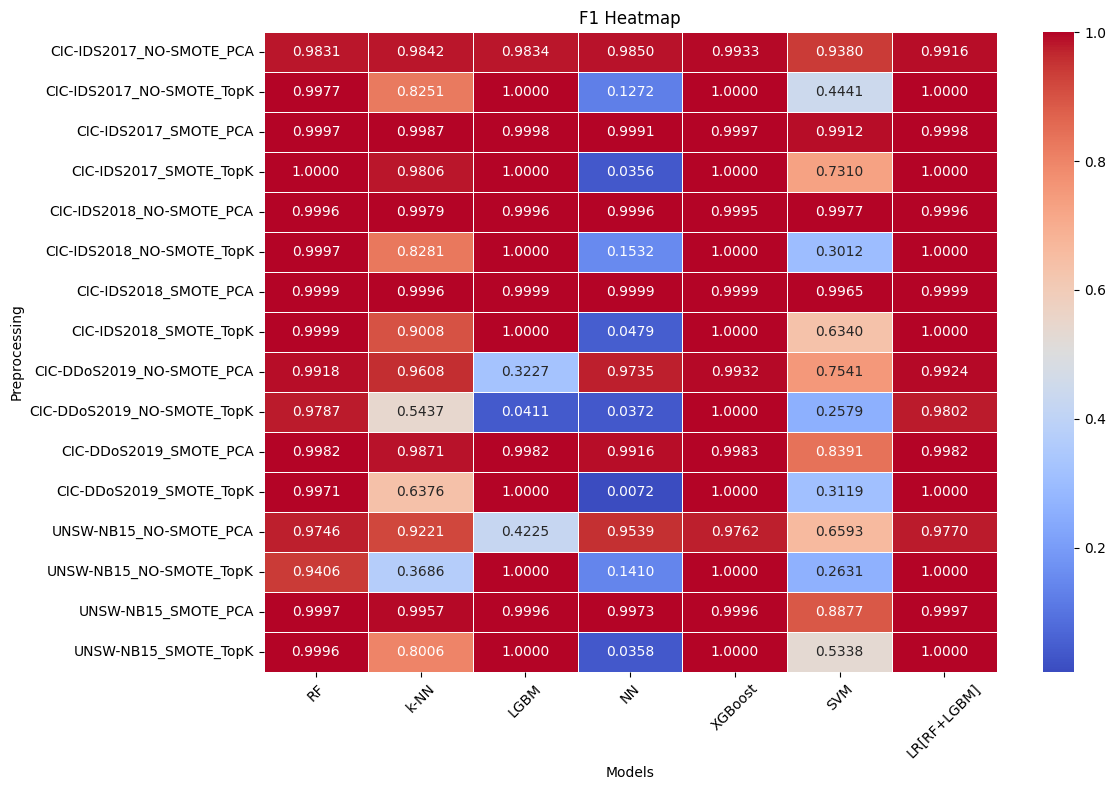

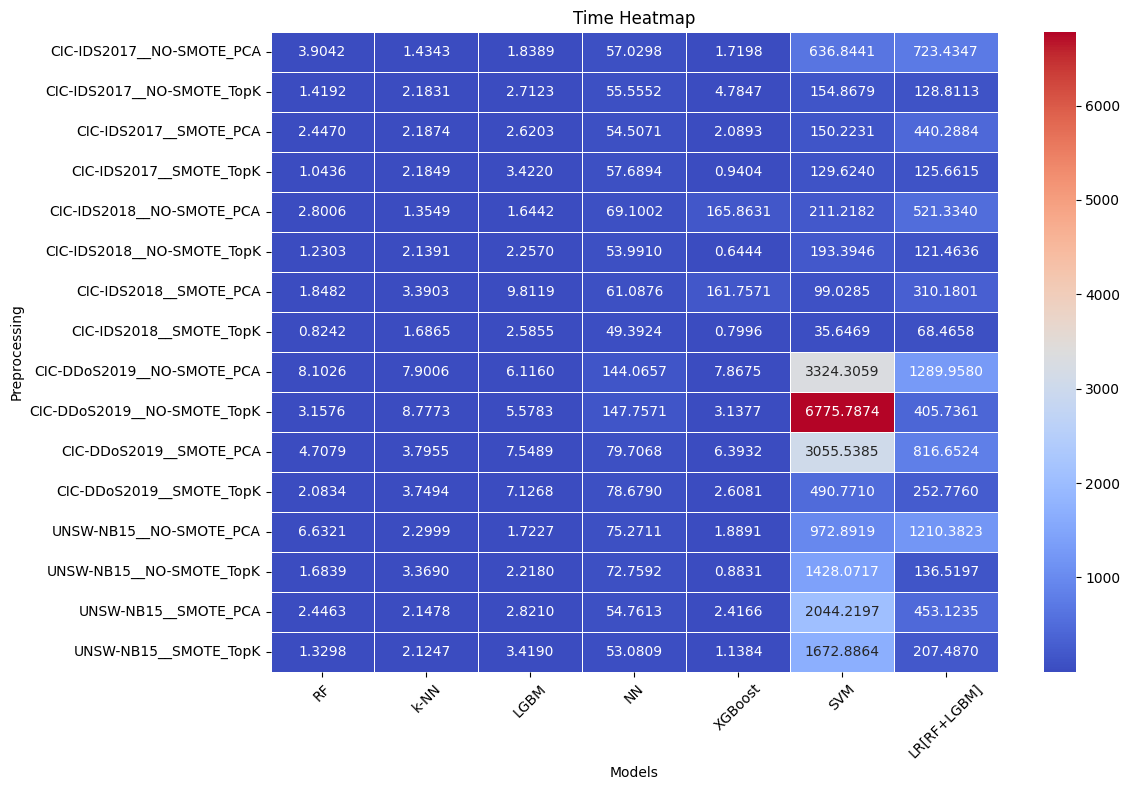

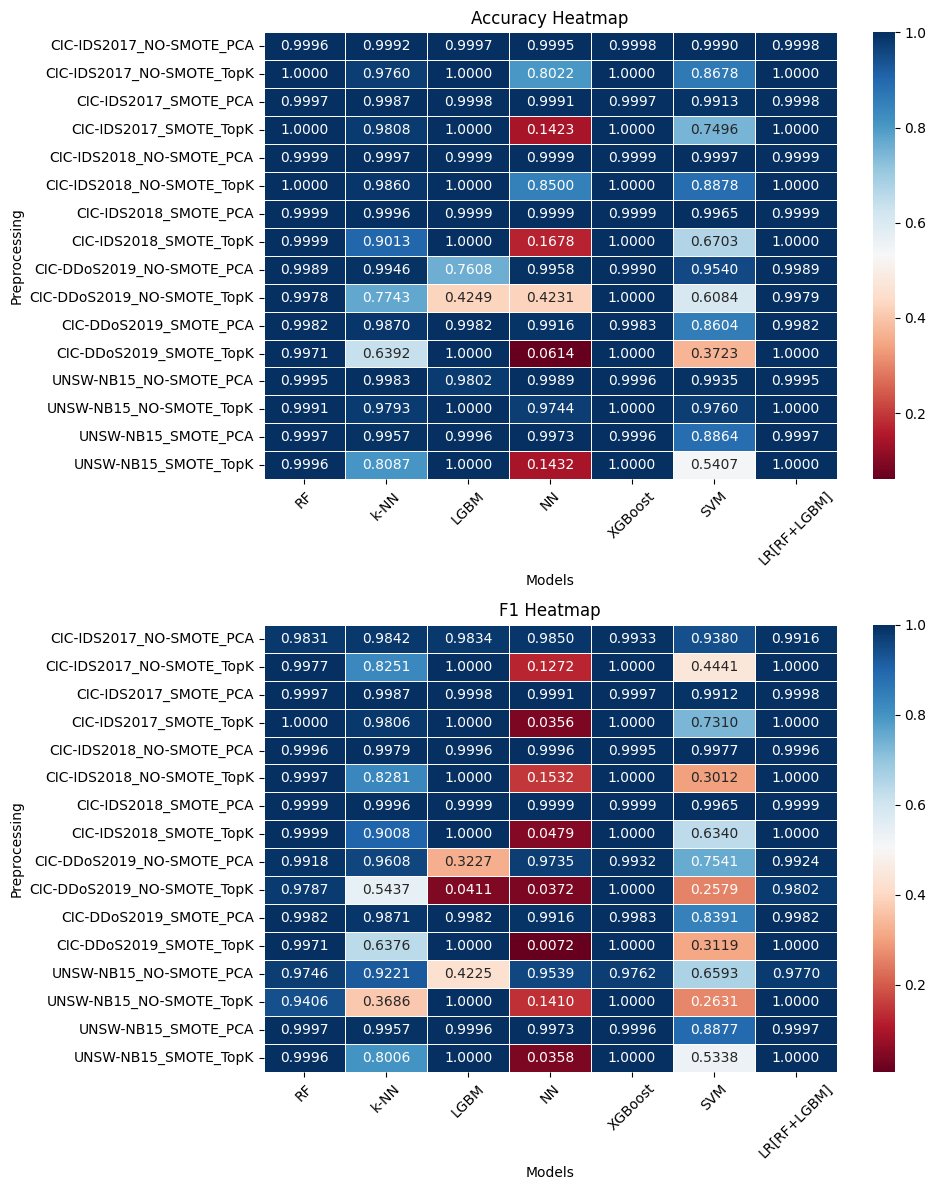

In [5]:
# filter accuracy values (Acc_)
def filter_accuracy_values(df):
    # Filter columns that start with 'Acc_'
    acc_columns = [col for col in df.columns if col.startswith('Acc_')]
    return df[acc_columns]

# filter f1 values (F1_)
def filter_f1_values(df):
    # Filter columns that start with 'F1_'
    f1_columns = [col for col in df.columns if col.startswith('F1_')]
    return df[f1_columns]

# filter Time values (Time_)
def filter_time_values(df):
    # Filter columns that start with 'Time_'
    time_columns = [col for col in df.columns if col.startswith('Time (s)')]
    return df[time_columns]

# get table with accuracy per each dataset
def get_accuracy_table(results):
    accuracy_tables = {}
    for dataset, df in results.items():
        accuracy_tables[dataset] = filter_accuracy_values(df)
    return accuracy_tables

# combine everything in a big heatmap, use 6 decimal points
def combine_heatmaps(results):
    combined_df = pd.DataFrame()
    for dataset, df in results.items():
        acc_table = filter_accuracy_values(df)
        acc_table.columns = [f"{dataset}_{col.replace('Acc_', '')}" for col in acc_table.columns]
        combined_df = pd.concat([combined_df, acc_table], axis=1)
    
    return combined_df.transpose()

combined_heatmap = combine_heatmaps(results)
plt.figure(figsize=(12, 8))
sns.heatmap(combined_heatmap, annot=True, fmt=".4f",cbar=True, cmap="coolwarm", linewidths=.5)
plt.title("Accuracy Heatmap")
plt.xlabel("Models")
plt.ylabel("Preprocessing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#get table with f1 per each dataset
def get_f1_table(results):
    f1_tables = {}
    for dataset, df in results.items():
        f1_tables[dataset] = filter_f1_values(df)
    return f1_tables
# combine everything in a big heatmap, use 4 decimal points
def combine_f1_heatmaps(results):
    combined_df = pd.DataFrame()
    for dataset, df in results.items():
        f1_table = filter_f1_values(df)
        f1_table.columns = [f"{dataset}_{col.replace('F1_', '')}" for col in f1_table.columns]
        combined_df = pd.concat([combined_df, f1_table], axis=1)
    
    return combined_df.transpose()
combined_f1_heatmap = combine_f1_heatmaps(results)
plt.figure(figsize=(12, 8))
sns.heatmap(combined_f1_heatmap, annot=True, fmt=".4f",cbar=True, cmap="coolwarm", linewidths=.5)
plt.title("F1 Heatmap")
plt.xlabel("Models")
plt.ylabel("Preprocessing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#get table with time per each dataset
def get_time_table(results):
    time_tables = {}
    for dataset, df in results.items():
        time_tables[dataset] = filter_time_values(df)
    return time_tables
# combine everything in a big heatmap, use 4 decimal points
def combine_time_heatmaps(results):
    combined_df = pd.DataFrame()
    for dataset, df in results.items():
        time_table = filter_time_values(df)
        time_table.columns = [f"{dataset}_{col.replace('Time (s)', '')}" for col in time_table.columns]
        combined_df = pd.concat([combined_df, time_table], axis=1)
    
    return combined_df.transpose()
combined_time_heatmap = combine_time_heatmaps(results)
plt.figure(figsize=(12, 8))
sns.heatmap(combined_time_heatmap, annot=True, fmt=".4f",cbar=True, linewidths=.5, cmap="coolwarm")
plt.title("Time Heatmap")
plt.xlabel("Models")
plt.ylabel("Preprocessing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# get all the heatmaps and save them as a combined figure
def save_combined_heatmaps():
    fig, axs = plt.subplots(2, 1, figsize=(10, 12))
    
    # Accuracy Heatmap
    sns.heatmap(combined_heatmap, annot=True, fmt=".4f", cbar=True, cmap="RdBu", linewidths=.5, ax=axs[0])
    axs[0].set_title("Accuracy Heatmap")
    axs[0].set_xlabel("Models")
    axs[0].set_ylabel("Preprocessing")
    axs[0].tick_params(axis='x', rotation=45)
    
    # F1 Heatmap
    sns.heatmap(combined_f1_heatmap, annot=True, fmt=".4f", cbar=True, cmap="RdBu", linewidths=.5, ax=axs[1])
    axs[1].set_title("F1 Heatmap")
    axs[1].set_xlabel("Models")
    axs[1].set_ylabel("Preprocessing")
    axs[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    
    # Save the combined figure
    plt.savefig('combined_heatmaps.png'
                , dpi=400, bbox_inches='tight') 
    
save_combined_heatmaps()


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

def combined_files(folder):
    # Get all image files in the folder

    # possible values
    datasets = ['CIC-IDS2017', 'CIC-IDS2018', 'CIC-IDS2019', 'UNSW']
    preproc = ['NO-SMOTE', '_SMOTE']
    feature = ['PCA', 'TopK']
    models = ['KNeighborsClassifier', 'LGBMClassifier', 'RandomForestClassifier', 'Sequential', 'StackingClassifier', 'SVC', 'XGBClassifier']

    classification_reports = {}

    for dataset in tqdm.tqdm(datasets, desc="Datasets"):
        for pre in preproc:
            for feat in feature:
                for model in models:
                    classification_report = [f for f in os.listdir(folder) if f.endswith('.csv') and dataset in f and pre in f and feat in f and model in f and 'classification_report' in f]
                    # read and put into a df
                    df = pd.read_csv(os.path.join(folder, classification_report[0]), index_col=0)
                    df.columns = ['Precision', 'Recall', 'F1-Score', 'Support']
                    # remove support column
                    df = df.drop(columns=['Support'])
                    # remove last 3 rows
                    df = df[:-3]
                    # save into a dictionary
                    classification_reports[f"{dataset}_{pre}_{feat}_{model}"] = df

    return classification_reports
       
# Example usage
folder = '/mnt/AI-DATA/alara/CiberIA_O1/Data'  # Replace with the folder containing your images
classification_reports = combined_files(folder)

Datasets: 100%|███████████████████████████████████████████████████████| 4/4 [00:00<00:00, 20.92it/s]


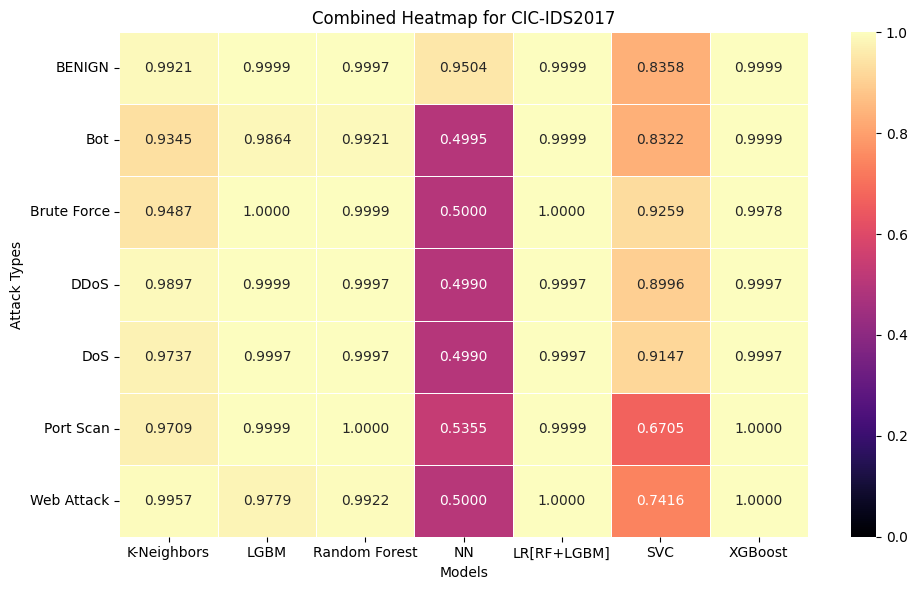

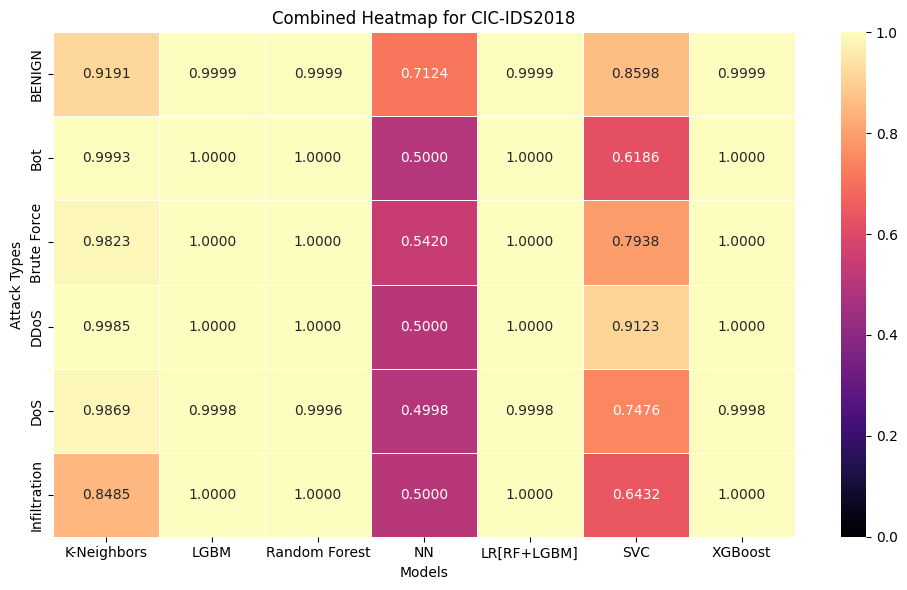

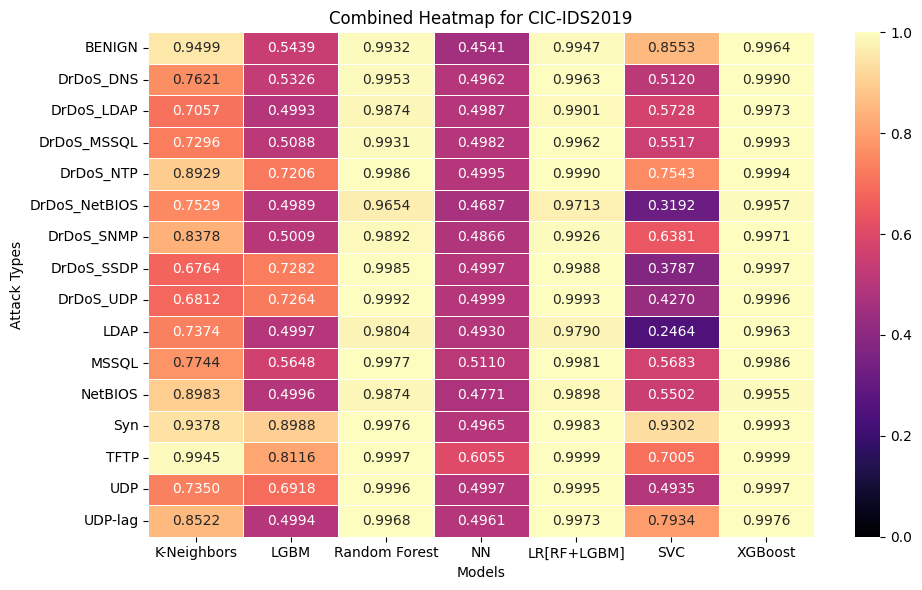

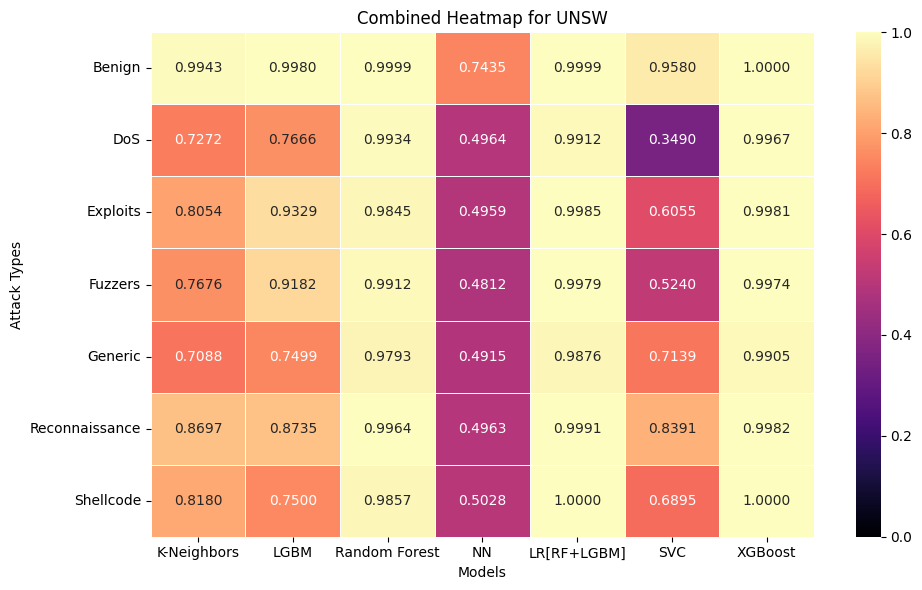

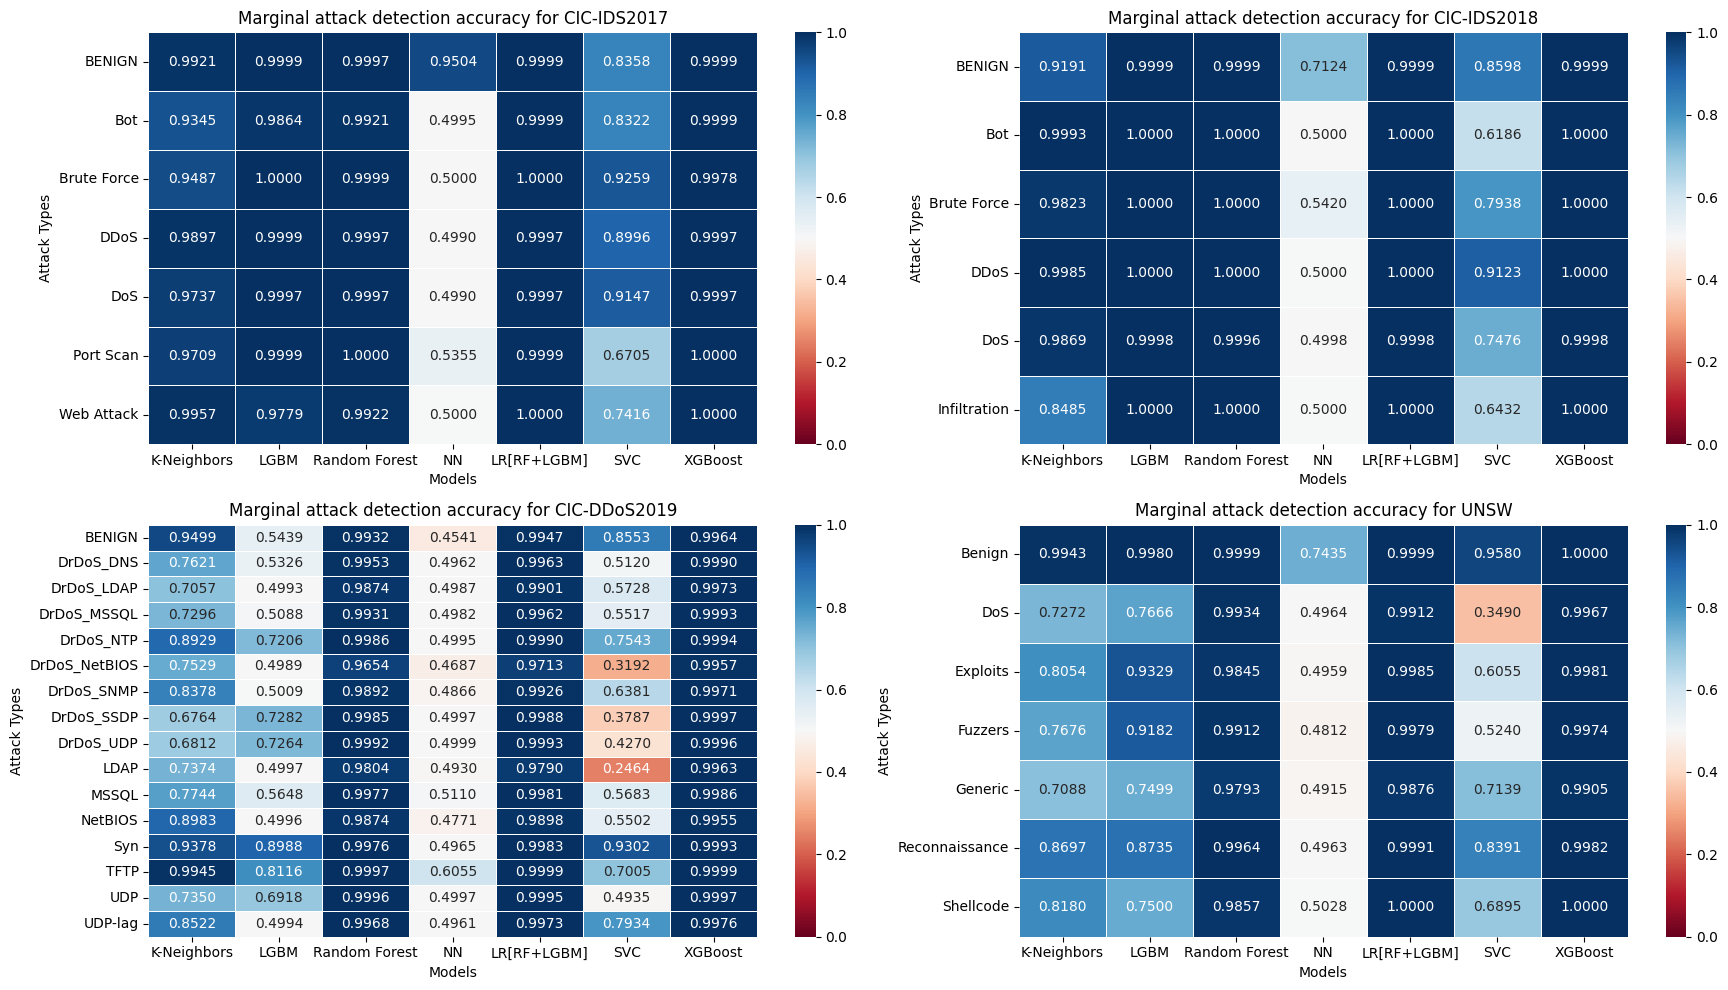

In [11]:
# for each dataset, compute the average per attack and per model
def compute_average_per_attack_per_model(classification_reports):
    # Create a dictionary to store the average classification reports per model
    average_reports_per_model = {}
    datasets = ['CIC-IDS2017', 'CIC-IDS2018', 'CIC-IDS2019', 'UNSW']
    models = ['KNeighborsClassifier', 'LGBMClassifier', 'RandomForestClassifier', 'Sequential', 'StackingClassifier', 'SVC', 'XGBClassifier']
    # Iterate through each dataset and model
    for dataset in datasets:
        average_reports_per_model[dataset] = {}
        for model in models:
            # Filter classification reports for the current dataset and model
            dataset_report = {key: value for key, value in classification_reports.items() if key.startswith(dataset) and key.endswith(model)}
            temp_df = pd.DataFrame()
            for key, df in dataset_report.items():
                # Drop 'Recall' and 'F1-Score' columns
                df = df.drop(columns=['Recall', 'F1-Score'], errors='ignore')

                temp_df = pd.concat([temp_df, df], axis=1)

            #compute the average for each row and leave only one column with the average
            temp_df = temp_df.T.groupby(temp_df.columns).mean().T

            # Store the result in the dictionary
            average_reports_per_model[dataset][model] = temp_df

    return average_reports_per_model

# Compute the average classification reports per attack per model
average_reports_per_model = compute_average_per_attack_per_model(classification_reports)

x_labels = ['K-Neighbors', 'LGBM', 'Random Forest', 'NN', 'LR[RF+LGBM]', 'SVC', 'XGBoost']
# Create a heatmap combining all models inside the same dataset
def plot_combined_heatmap(average_reports_per_model):
    for dataset, models in average_reports_per_model.items():
        # Combine all models into a single DataFrame
        combined_df = pd.DataFrame()
        for model_name, report in models.items():
            combined_df[model_name] = report['Precision']
        
        # Rename x labels with the array x_labels
        combined_df.columns = x_labels

        # Plot the heatmap
        plt.figure(figsize=(10, 6))
        sns.heatmap(combined_df, annot=True, fmt=".4f", linewidths=.5, cmap="magma", cbar=True, vmin=0, vmax=1)
        plt.title(f"Combined Heatmap for {dataset}")
        plt.xlabel("Models")
        plt.ylabel("Attack Types")
        plt.tight_layout()
        plt.show()

# Plot the combined heatmaps
plot_combined_heatmap(average_reports_per_model)

# combine the hetamps in a 2x2 grid and save it
def plot_combined_heatmap_grid(average_reports_per_model):
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    datasets = list(average_reports_per_model.keys())
    
    for i, (dataset, models) in enumerate(average_reports_per_model.items()):
        # Combine all models into a single DataFrame
        combined_df = pd.DataFrame()
        for model_name, report in models.items():
            combined_df[model_name] = report['Precision']
        
        # Rename x labels with the array x_labels
        combined_df.columns = x_labels

        # Plot the heatmap
        ax = axs[i // 2, i % 2]
        sns.heatmap(combined_df, annot=True, fmt=".4f", linewidths=.5, cmap="RdBu", cbar=True, vmin=0, vmax=1, ax=ax)
        if '2019' in dataset:
            dataset = 'CIC-DDoS2019'
        ax.set_title(f"Marginal attack detection accuracy for {dataset}")
        ax.set_xlabel("Models")
        ax.set_ylabel("Attack Types")
    
    plt.tight_layout()
    plt.savefig('combined_heatmaps_grid.png', dpi=400)
    plt.show()

# Plot the combined heatmaps in a 2x2 grid
plot_combined_heatmap_grid(average_reports_per_model)